
Cl_R1s(r) =
+81.8257 * exp(-25.5708 r)
+67.0530 * exp(-15.6262 r)
+459.8012 * r * exp(-22.3994 r)
+0.1695 * r * exp(-10.5300 r)
+0.3709 * r * exp(-7.0534 r)
-0.0677 * r * exp(-5.4120 r)
-123.8881 * r^2 * exp(-46.7052 r)
+0.0030 * r^2 * exp(-3.7982 r)
-0.0007 * r^2 * exp(-2.5495 r)
+0.0000 * r^2 * exp(-1.7965 r)

Cl_R2s(r) =
+20.4685 * exp(-25.5708 r)
-62.7368 * exp(-15.6262 r)
+164.2431 * r * exp(-22.3994 r)
-10.9639 * r * exp(-10.5300 r)
+127.0346 * r * exp(-7.0534 r)
+23.2516 * r * exp(-5.4120 r)
+63.7055 * r^2 * exp(-46.7052 r)
+0.0992 * r^2 * exp(-3.7982 r)
+0.0159 * r^2 * exp(-2.5495 r)
+0.0006 * r^2 * exp(-1.7965 r)

Cl_R3s(r) =
+9.1838 * exp(-25.5708 r)
-22.3939 * exp(-15.6262 r)
+72.6618 * r * exp(-22.3994 r)
+2.6092 * r * exp(-10.5300 r)
+17.0627 * r * exp(-7.0534 r)
+30.3393 * r * exp(-5.4120 r)
+20.5502 * r^2 * exp(-46.7052 r)
-16.9703 * r^2 * exp(-3.7982 r)
-6.6221 * r^2 * exp(-2.5495 r)
-0.7535 * r^2 * exp(-1.7965 r)

Cl_R2p(r) =
+10.2994 * r * exp(-26.6358 r)
-76.6831 * 

/tmp/ipykernel_32020/2218090718.py:106: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  val = np.sqrt(2/np.pi) * np.trapz(integrand, r_grid)


           Q  J_1s_one_electron  J_2s_one_electron  J_3s_one_electron  \
0       0.00       4.902616e-02       1.984261e-01       6.480324e-01   
1       0.05       4.902489e-02       1.983470e-01       6.451225e-01   
2       0.10       4.902110e-02       1.981099e-01       6.364817e-01   
3       0.15       4.901478e-02       1.977154e-01       6.223713e-01   
4       0.20       4.900594e-02       1.971648e-01       6.032102e-01   
...      ...                ...                ...                ...   
1996   99.80       9.188253e-07       7.754471e-08       7.610473e-09   
1997   99.85       9.147783e-07       7.720079e-08       7.576698e-09   
1998   99.90       9.107448e-07       7.685803e-08       7.543038e-09   
1999   99.95       9.067250e-07       7.651645e-08       7.509494e-09   
2000  100.00       9.027186e-07       7.617604e-08       7.476064e-09   

      J_2p_one_electron  J_3p_one_electron   J_1s(2)       J_2s(2)  \
0          1.019054e-01       4.415540e-01  0.098052 

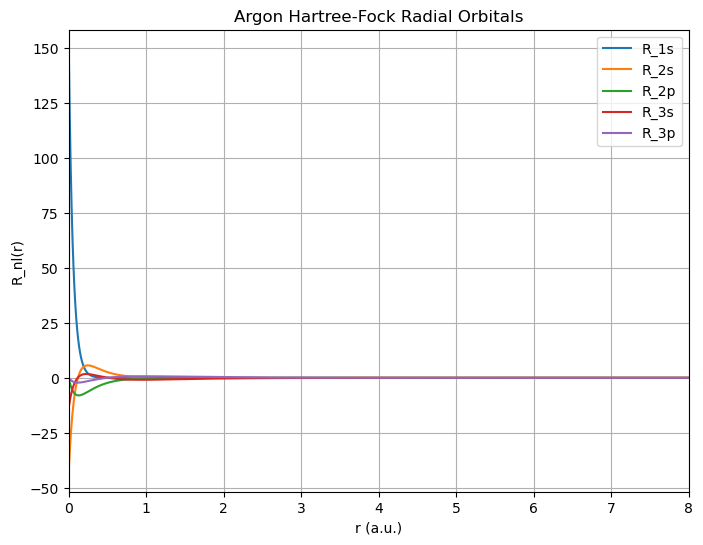

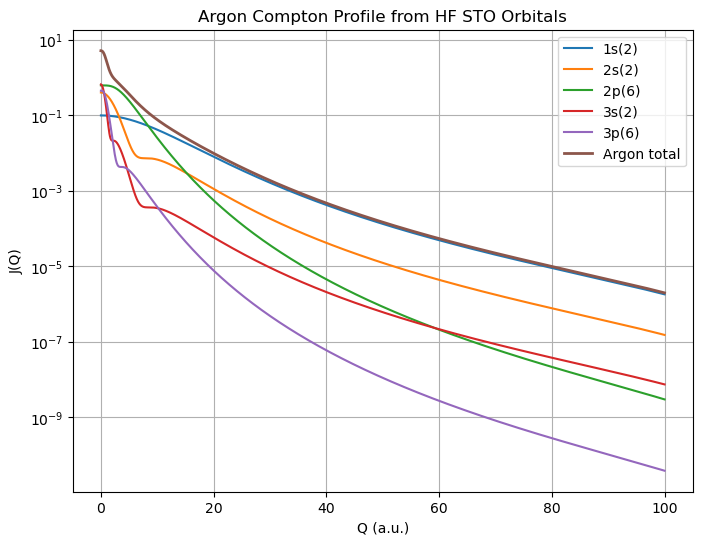

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import spherical_jn, factorial
from scipy.integrate import cumulative_trapezoid

# =====================================================
# Argon Hartree-Fock STO data
# Ar: 1s(2) 2s(2) 2p(6) 3s(2) 3p(6)
# Format: (n_j, Z_j, C_j)
# =====================================================

argon_1s = [
    (1,25.5708,  0.316405),
    (1,15.6262,  0.542760),
    (2,22.3994,  0.167691),
    (2,10.5300,  0.000408),
    (2, 7.0534,  0.002431),
    (2, 5.4120, -0.000861),
    (3,46.7052, -0.000422),
    (3, 3.7982,  0.000066),
    (3, 2.5495, -0.000061),
    (3, 1.7965,  0.000009),
]

argon_2s = [
    (1,25.5708,  0.079148),
    (1,15.6262, -0.507823),
    (2,22.3994,  0.059900),
    (2,10.5300, -0.026389),
    (2, 7.0534,  0.832638),
    (2, 5.4120,  0.295522),
    (3,46.7052,  0.000217),
    (3, 3.7982,  0.002203),
    (3, 2.5495,  0.001423),
    (3, 1.7965,  0.000186),
]

argon_3s = [
    (1,25.5708,  0.035512),
    (1,15.6262, -0.181267),
    (2,22.3994,  0.026500),
    (2,10.5300,  0.006280),
    (2, 7.0534,  0.111836),
    (2, 5.4120,  0.385604),
    (3,46.7052,  0.000070),
    (3, 3.7982, -0.376901),
    (3, 2.5495, -0.593561),
    (3, 1.7965, -0.229971),
]

argon_2p = [
    (2,26.6358,  0.002436),
    (2,12.7337, -0.114774),
    (2, 7.3041, -0.503175),
    (2, 5.3353, -0.427033),
    (3,20.7765,  0.009669),
    (3, 3.3171,  0.004825),
    (3, 2.0947,  0.000231),
    (3, 1.3780, -0.000098),
]

argon_3p = [
    (2,26.6358,  0.001854),
    (2,12.7337, -0.042064),
    (2, 7.3041, -0.095603),
    (2, 5.3353, -0.194233),
    (3,20.7765,  0.005891),
    (3, 3.3171,  0.366141),
    (3, 2.0947,  0.526490),
    (3, 1.3780,  0.249866),
]
# =====================================================
# STO normalization constant
# N_j = sqrt((2Z)^(2n+1)/(2n)!)
# =====================================================

def N_sto(n, Z):
    return np.sqrt((2*Z)**(2*n + 1) / factorial(2*n, exact=False))

def R_nl(r, coeffs):
    R = np.zeros_like(r)
    for n, Z, C in coeffs:
        N = N_sto(n, Z)
        R += C * N * r**(n-1) * np.exp(-Z*r)
    return R
# =====================================================
# Grids
# =====================================================

r = np.linspace(1e-6, 60.0, 20000)     # radial grid
p = np.arange(0.0, 120.0 + 0.05, 0.05) # momentum grid
Q = np.arange(0.0, 100.0 + 0.05, 0.05) # Q grid

# =====================================================
# Calculate chi_nl(p)
# chi_nl(p) = sqrt(2/pi) int R_nl(r) j_l(pr) r^2 dr
# =====================================================

def chi_p(p_grid, r_grid, R_grid, l):
    chi = []

    for pp in p_grid:
        jl = spherical_jn(l, pp*r_grid)
        integrand = R_grid * jl * r_grid**2
        val = np.sqrt(2/np.pi) * np.trapz(integrand, r_grid)
        chi.append(val)

    return np.array(chi)

# =====================================================
# Calculate J(Q)
# I(p) = |chi(p)|^2 p^2
# J(Q) = 1/2 int_Q^inf I(p)/p dp
# =====================================================

def calculate_J(p_grid, chi_grid, Q_grid):
    I = chi_grid**2 * p_grid**2

    integrand = np.zeros_like(p_grid)
    integrand[1:] = I[1:] / p_grid[1:]

    # Reverse cumulative integral from p to infinity
    rev_integral = cumulative_trapezoid(
        integrand[::-1],
        p_grid[::-1],
        initial=0
    )

    J_p = -0.5 * rev_integral[::-1]

    # Interpolate J from p-grid to Q-grid
    J_Q = np.interp(Q_grid, p_grid, J_p)

    return I, J_Q

# =====================================================
# Build Argon radial orbitals
# =====================================================
def print_R_formula(coeffs, name):
    print(f"\n{name}(r) =")

    for n, Z, C in coeffs:
        N = N_sto(n, Z)
        A = C * N

        if n == 1:
            print(f"{A:+.4f} * exp(-{Z:.4f} r)")
        elif n == 2:
            print(f"{A:+.4f} * r * exp(-{Z:.4f} r)")
        elif n == 3:
            print(f"{A:+.4f} * r^2 * exp(-{Z:.4f} r)")
            
R1s = R_nl(r, argon_1s)
R2s = R_nl(r, argon_2s)
R3s = R_nl(r, argon_3s)
R2p = R_nl(r, argon_2p)
R3p = R_nl(r, argon_3p)

print_R_formula(argon_1s, "Cl_R1s")
print_R_formula(argon_2s, "Cl_R2s")
print_R_formula(argon_3s, "Cl_R3s")
print_R_formula(argon_2p, "Cl_R2p")
print_R_formula(argon_3p, "Cl_R3p")

# =====================================================
# Momentum-space wavefunctions
# =====================================================

chi_1s = chi_p(p, r, R1s, l=0)
chi_2s = chi_p(p, r, R2s, l=0)
chi_3s = chi_p(p, r, R3s, l=0)
chi_2p = chi_p(p, r, R2p, l=1)
chi_3p = chi_p(p, r, R3p, l=1)

# =====================================================
# Momentum densities and Compton profiles
# =====================================================

I_1s, J_1s = calculate_J(p, chi_1s, Q)
I_2s, J_2s = calculate_J(p, chi_2s, Q)
I_3s, J_3s = calculate_J(p, chi_3s, Q)
I_2p, J_2p = calculate_J(p, chi_2p, Q)
I_3p, J_3p = calculate_J(p, chi_3p, Q)

# Chlorine has 1s(2) 2s(2) 2s(2) 2p(6) 3s(2) 3p(5)
J_total = 2*J_1s + 2*J_2s + 6*J_2p + 2*J_3s + 6*J_3p

# =====================================================
# Print and save table
# =====================================================
table = pd.DataFrame({
    "Q": Q,
    "J_1s_one_electron": J_1s,
    "J_2s_one_electron": J_2s,
    "J_3s_one_electron": J_3s,
    "J_2p_one_electron": J_2p,
    "J_3p_one_electron": J_3p,
    "J_1s(2)": 2*J_1s,
    "J_2s(2)": 2*J_2s,
    "J_2p(6)": 6*J_2p,
    "J_3s(2)": 2*J_3s,
    "J_3p(6)": 6*J_3p,
    "J_total_Chlorine": J_total
})
print(table)
table.to_csv("Argon_HF_Compton_profile.csv", index=False)

# =====================================================
# Plot radial orbitals
# =====================================================

plt.figure(figsize=(8,6))
plt.plot(r, R1s, label="R_1s")
plt.plot(r, R2s, label="R_2s")
plt.plot(r, R2p, label="R_2p")
plt.plot(r, R3s, label="R_3s")
plt.plot(r, R3p, label="R_3p")
plt.xlim(0, 8)
plt.xlabel("r (a.u.)")
plt.ylabel("R_nl(r)")
plt.title("Argon Hartree-Fock Radial Orbitals")
plt.grid(True)
plt.legend()
plt.show()

# =====================================================
# Plot Compton profiles
# =====================================================
plt.figure(figsize=(8,6))
plt.plot(Q, 2*J_1s, label="1s(2)")
plt.plot(Q, 2*J_2s, label="2s(2)")
plt.plot(Q, 6*J_2p, label="2p(6)")
plt.plot(Q, J_3s, label="3s(2)")
plt.plot(Q, J_3p, label="3p(6)")
plt.plot(Q, J_total, label="Argon total", linewidth=2)

plt.xlabel("Q (a.u.)")
plt.ylabel("J(Q)")
plt.title("Argon Compton Profile from HF STO Orbitals")
plt.yscale("log")
plt.grid(True)
plt.legend()
plt.show()